In [3]:
pd.read_csv("Sample - Superstore.csv")

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa0 in position 2944: invalid start byte

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("Sample - Superstore.csv", encoding='latin-1')

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
df.shape

(9994, 21)

In [8]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print(category_sales)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


In [9]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

print(region_sales)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


In [10]:
city_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False)

print(city_sales.head(10))


City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Name: Sales, dtype: float64


In [11]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True, errors="coerce")

In [12]:
print(df["Order Date"].dtype)

datetime64[us]


In [13]:
df["Month"] = df["Order Date"].dt.month

In [14]:
df["Year_Month"] = df["Order Date"].dt.to_period("M")

In [15]:
monthly_sales = df.groupby("Year_Month")["Sales"].sum()

print(monthly_sales)

Year_Month
2014-01    19640.4270
2014-02    11833.6180
2014-03     7159.6700
2014-04    12455.4820
2014-05    15280.4110
2014-06    11927.8490
2014-07    10222.4280
2014-08    26797.7630
2014-09    17158.9320
2014-10    10112.6410
2014-11    18792.1840
2014-12    17525.2847
2015-01    17701.6864
2015-02    13018.3150
2015-03    12207.4066
2015-04    11963.6960
2015-05    10483.4820
2015-06    13112.6482
2015-07    10706.7200
2015-08    23800.1750
2015-09    16484.9010
2015-10    12686.2240
2015-11    12139.0395
2015-12     9909.1910
2016-01    26342.5410
2016-02    43298.7350
2016-03    26053.3750
2016-04    22296.3940
2016-05    22777.4588
2016-06    15617.4050
2016-07    16571.2790
2016-08    24156.3226
2016-09     9789.6620
2016-10    22636.6540
2016-11    20477.8080
2016-12    21472.2185
2017-01    31839.9120
2017-02    36988.4560
2017-03    26899.4730
2017-04    21446.7670
2017-05    15979.1570
2017-06    12648.9558
2017-07    25110.4795
2017-08    26823.6900
2017-09    23148.8700

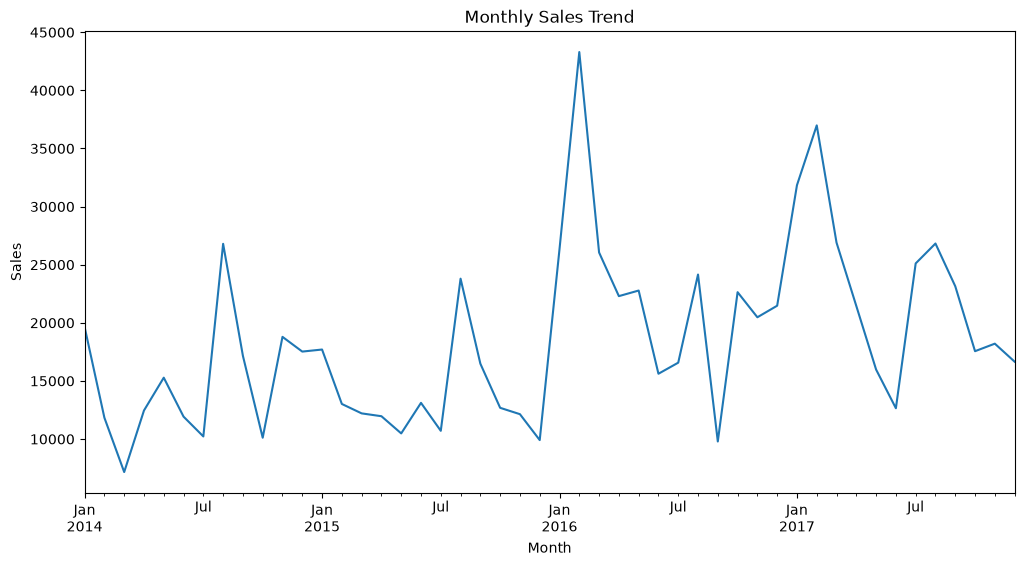

In [18]:
plt.figure(figsize=(12,6))
monthly_sales.plot(kind="line")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

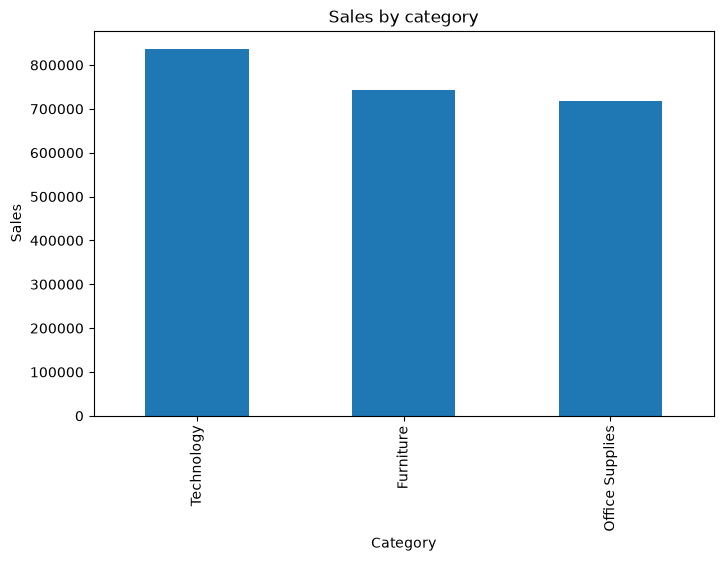

In [17]:
category_sales.plot(kind="bar",figsize=(8,5))
plt.title("Sales by category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

In [24]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False)

In [25]:
print (top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
                                                                                 ...    
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                                 7.700
Grip Seal Envelopes                                                                7.072
Xerox 20                                                                           6.480
Avery 5                                                                            5.760
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac                   1.624
Name: Sa

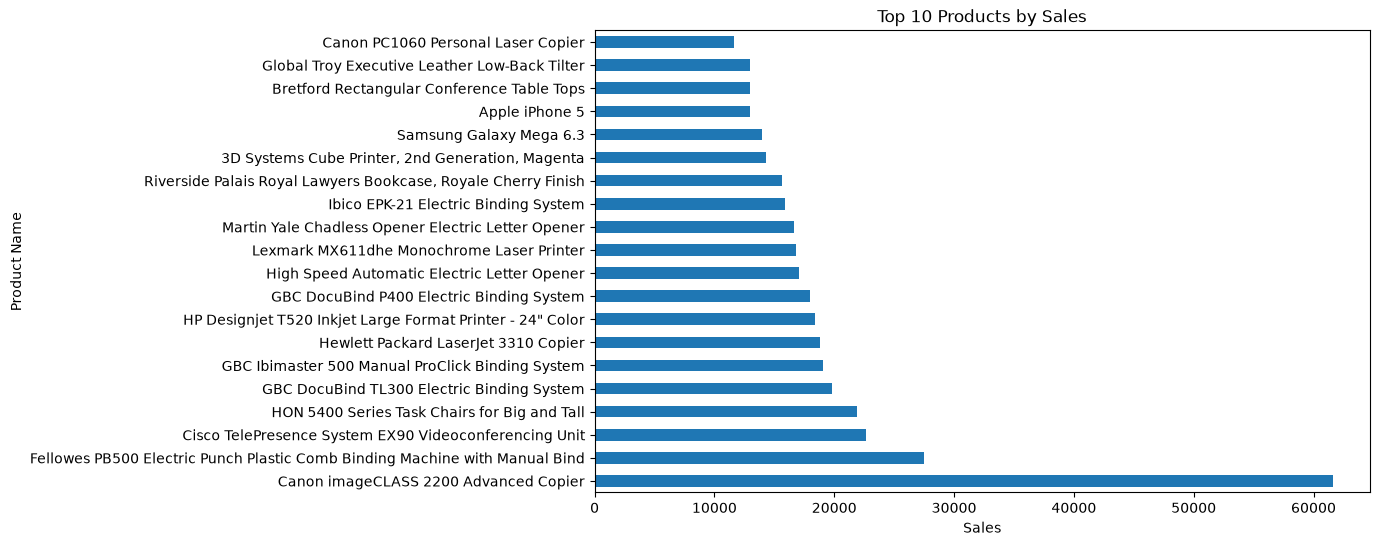

In [27]:
top_products.head(20).plot(
    kind="barh",
    figsize=(10,6)
)
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.show()

In [33]:
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
print (category_profit)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


In [32]:
discount_profit = df.groupby("Discount")["Profit"].mean()

print(discount_profit)

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64


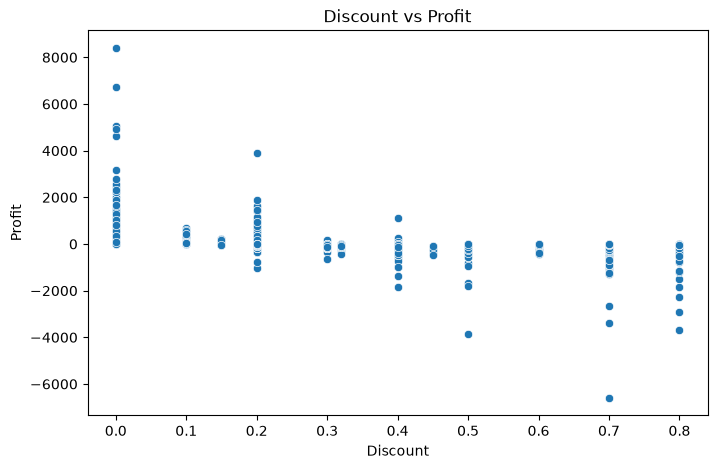

In [38]:
plt.figure(figsize=(8,5))
sns.scatterplot( 
               data=df,
               x="Discount",
               y="Profit"
           )
plt.title ("Discount vs Profit")
plt.show()           